<img src = "https://slitayem.github.io/img/blog/2020-08-04/churn.png" width=50%>

## Importing the libraries

In [64]:
import numpy as np
import pandas as pd
import seaborn as sns

#from pycaret.classification import * 
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

import joblib
from Preprocessing import Preprocessing

## Load and Prepare Data

In [65]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## EDA

In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [67]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Data Preprocessing

In [68]:
df.drop(columns=['RowNumber' , 'CustomerId' ,'Surname' , 'Tenure' , 'HasCrCard'] , inplace=True)


In [69]:
num_cols = df.select_dtypes(include=np.number).drop(columns=['Exited' , 'Age'] ).columns.tolist()
total_outliers_fixed = 0
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outlier_count = outlier_mask.sum()
    if outlier_count > 0:
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
        total_outliers_fixed += outlier_count
        print(f"  - '{col}': {outlier_count} outliers clipped")

  - 'CreditScore': 15 outliers clipped
  - 'NumOfProducts': 60 outliers clipped


In [70]:
df['Gender'] = df.Gender.map({
    'Male':0,
    'Female':1
})

In [71]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

## Strorytelling - Visualization

In [8]:
coor = df.corr()
sns.heatmap(coor , annot=True)

ValueError: could not convert string to float: 'France'

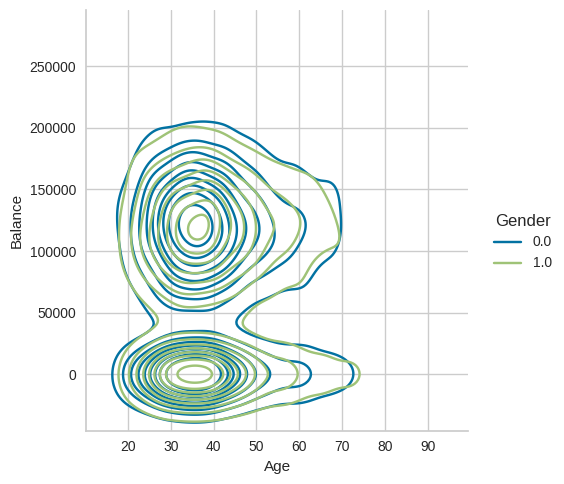

In [ ]:
sns.displot(data= df , x='Age' , y='Balance',hue='Gender' ,kind='kde')

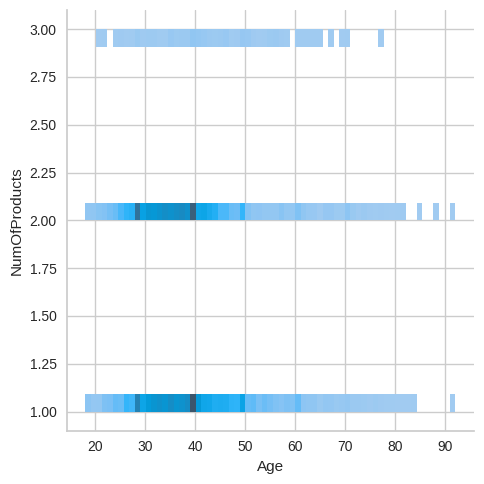

In [ ]:
sns.displot(data= df , x='Age' , y='NumOfProducts')


In [ ]:
df.columns

Index(['CreditScore', 'Gender', 'Age', 'Balance', 'NumOfProducts',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

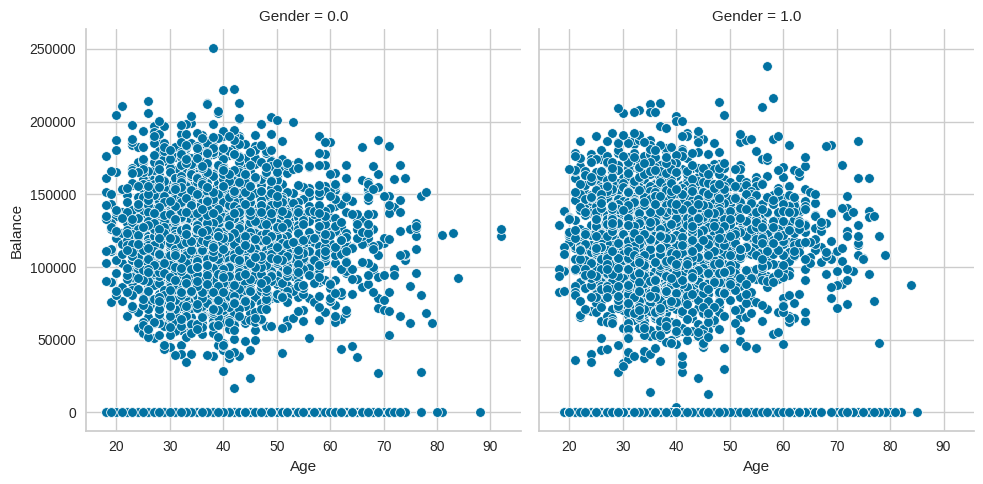

In [ ]:
sns.relplot(x='Age' , y='Balance' , data=df ,col='Gender')

## Prepare Data for Machine learning

In [72]:
X = df.drop('Exited' , axis=1)
y = df['Exited']

In [73]:
y.value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [101]:
# فرض کنید y یک pandas Series است
minority_class = 1   # کلاس کم‌تکرار
majority_class = 0

# ایندکس‌های هر کلاس
idx_minority = y[y == minority_class].index
idx_majority = y[y == majority_class].index

# نمونه‌گیری از کلاس اکثریت به اندازه کلاس اقلیت
idx_majority_sampled = np.random.choice(idx_majority, size=len(idx_minority), replace=False)

# ترکیب ایندکس‌ها
balanced_idx = idx_minority.union(idx_majority_sampled)

# اعمال روی دیتافریم اصلی
X = X.loc[balanced_idx]
y = y.loc[balanced_idx]

In [102]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

# شناسایی ستون‌ها
categorical_cols = ['Geography', 'Gender']
numerical_cols = ['CreditScore', 'Age', 'Balance', 'NumOfProducts', 'IsActiveMember', 'EstimatedSalary']

# ساخت preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='if_binary', dtype=int), categorical_cols)
    ]
)


gbc = GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=3505, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)

# Pipeline کامل
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', gbc)
])

# تقسیم داده‌ها
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=34143543
)

# آموزش
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Balance', 'NumOfProducts',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                dtype=<class 'int'>),
                                                  ['Geography', 'Gender'])])),
                ('classifier', GradientBoostingClassifier(random_state=3505))])

## Test the model and show the metrics

In [103]:
accuracies = cross_val_score(estimator = model, X = X_train, y = y_train, cv = 10 , verbose=100 , n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[CV] START .....................................................................
[CV] START .....................................................................
[CV] START .....................................................................
[CV] START .....................................................................
[CV] END ................................ score: (test=0.791) total time=   1.1s
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    6.0s
[CV] END ................................ score: (test=0.745) total time=   1.0s
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    6.0s
[CV] START .....................................................................
[CV] START .....................................................................
[CV] END ................................ score: (test=0.791) total time=   1.2s
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:    6.1s
[CV] END 

In [104]:
print("Accuracy train: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy train: 77.91 %
Standard Deviation: 1.86 %


In [105]:
yhat = model.predict(X_test)
print('Accrurcy test = {:.2f}%'.format(accuracy_score (yhat , y_test) *100))

Accrurcy test = 78.65%


## Save your final model

In [106]:
joblib.dump(model , 'pipeline_predict_churn.pkl')

['pipeline_predict_churn.pkl']

In [107]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import joblib

# بارگذاری داده
df = pd.read_csv('Churn_Modelling.csv')
df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Tenure', 'HasCrCard'], inplace=True)

# جداسازی ویژگی‌ها و هدف
X = df.drop('Exited', axis=1)
y = df['Exited']

# تقسیم به Train/Test (برای نمونه‌گیری متوازن، مطابق کد قبلی)
# ... (در صورت نیاز داده‌ها را متوازن کنید)

# شناسایی ستون‌ها
categorical_cols = ['Geography', 'Gender']
numerical_cols = ['CreditScore', 'Age', 'Balance', 'NumOfProducts', 'IsActiveMember', 'EstimatedSalary']

# پیش‌پردازشگر
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)  # drop='first' برای جلوگیری از همخطی
    ]
)

# مدل نهایی
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=3505
    ))
])

# آموزش
pipeline.fit(X, y)

# ذخیره پایپ‌لاین کامل
joblib.dump(pipeline, 'full_pipeline.pkl')

['full_pipeline.pkl']

## Send us the Result (Maktabkhoone)

In [ ]:
setup(data=df , fold=3, target='Exited')

,Description,Value
0,Session id,5171
1,Target,Exited
2,Target type,Binary
3,Original data shape,"(9926, 8)"
4,Transformed data shape,"(9926, 8)"
5,Transformed train set shape,"(6948, 8)"
6,Transformed test set shape,"(2978, 8)"
7,Numeric features,7
8,Preprocess,True
9,Imputation type,simple


In [ ]:
compare_models(exclude=['tr'])

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,03:09:06
Status,. . . . . . . . . . . . . . . . . .,Fitting 3 Folds
Estimator,. . . . . . . . . . . . . . . . . .,Random Forest Classifier


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.8117,0.7461,0.1521,0.5988,0.2422,0.1758,0.2308,2.5333
ridge,Ridge Classifier,0.8063,0.7486,0.0662,0.6004,0.1191,0.0826,0.1501,0.0667
nb,Naive Bayes,0.7902,0.7321,0.0422,0.2890,0.0729,0.0245,0.0392,0.0767
svm,SVM - Linear Kernel,0.7781,0.4861,0.0553,0.0792,0.0651,0.0130,0.0133,0.1133
dt,Decision Tree Classifier,0.7773,0.6635,0.4753,0.4421,0.4579,0.3181,0.3185,0.1033
knn,K Neighbors Classifier,0.7668,0.5192,0.0677,0.2150,0.1029,0.0092,0.0112,0.9800


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
ETC = create_model('gbc')

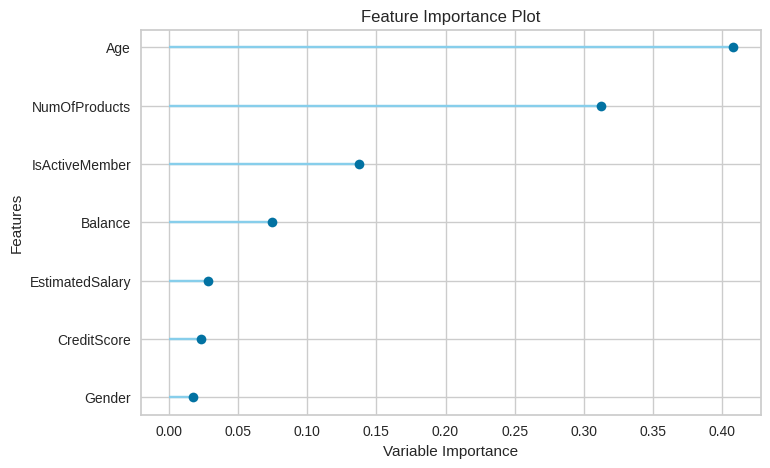

In [ ]:
plot_model(estimator=ETC , plot='feature')